Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows in trades: 0

Sentiment Analysis:
                Closed PnL                 win     Size USD
                     mean    median      mean         mean
classification                                            
Extreme Fear     5.140932  0.000000  0.294296  4092.776491
Extreme Greed   66.647938  0.886912  0.550957  2881.858972
Fear            45.958507  0.000000  0.376857  4860.957261
Greed           39.496717 

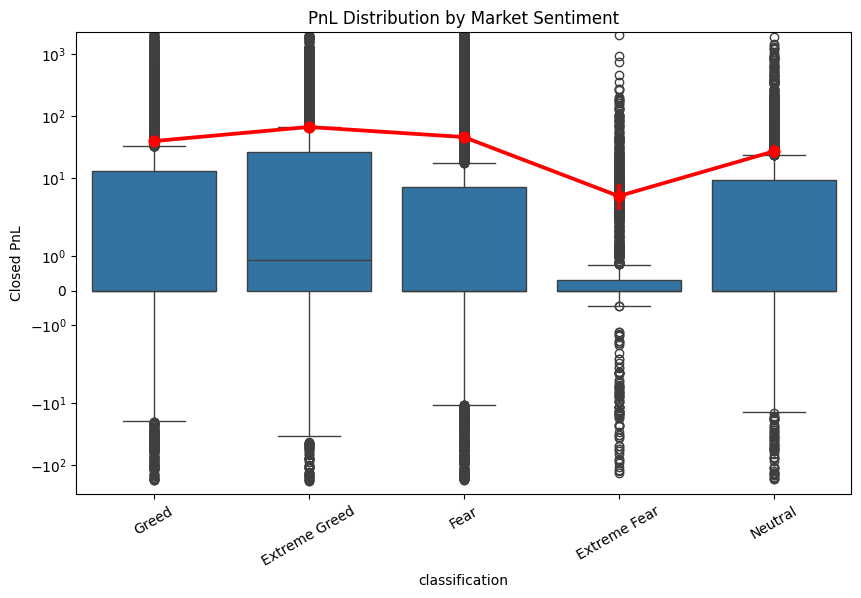


Trade Size by Sentiment:
 classification
Extreme Fear     4092.776491
Extreme Greed    2881.858972
Fear             4860.957261
Greed            4268.656657
Neutral          4111.310708
Name: Size USD, dtype: float64

Trades Count by Sentiment:
 classification
Fear             13533
Greed            11073
Extreme Greed     5485
Neutral           2742
Extreme Fear      2314
Name: count, dtype: int64

Segment Analysis (Freq vs Sentiment):
 freq_group  classification
0           Extreme Fear      12.289279
            Extreme Greed     98.166030
            Fear              56.544985
            Greed             79.942795
            Neutral           36.391685
1           Extreme Fear       4.112673
            Extreme Greed     64.850028
            Fear              44.962254
            Greed             37.435257
            Neutral           26.874866
Name: Closed PnL, dtype: float64

Winner Analysis:
 winner  classification
False   Extreme Fear       2.983652
        Extreme Gre

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

# ==============================
# 2. LOAD DATA
# ==============================
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv", on_bad_lines='skip', low_memory=False)

# ==============================
# 3. BASIC CHECKS
# ==============================
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values (Sentiment):\n", sentiment.isnull().sum())
print("\nMissing Values (Trades):\n", trades.isnull().sum())

print("\nDuplicate rows in trades:", trades.duplicated().sum())

# ==============================
# 4. DATE CONVERSION
# ==============================
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

# Create common Date column
sentiment['Date'] = sentiment['date'].dt.date
trades['Date'] = trades['Timestamp IST'].dt.date

# ==============================
# 5. MERGE DATASETS
# ==============================
merged = pd.merge(trades, sentiment, on='Date', how='left')

# ==============================
# 6. CLEAN IMPORTANT COLUMNS
# ==============================
# Convert numeric columns safely
numeric_cols = ['Closed PnL', 'Size USD'] # Removed 'leverage'
for col in numeric_cols:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

# Drop rows with missing critical values
merged = merged.dropna(subset=['Closed PnL', 'classification'])

# ==============================
# 7. FEATURE ENGINEERING
# ==============================

# Profitability flag
merged['profitable'] = merged['Closed PnL'] > 0

# Win column
merged['win'] = merged['Closed PnL'] > 0

# Trade count per account
trade_counts = merged.groupby('Account').size()

# Frequent traders
frequent_accounts = trade_counts[trade_counts > trade_counts.median()].index
merged['freq_group'] = merged['Account'].isin(frequent_accounts).astype(int)

# Total PnL per account
total_pnl = merged.groupby('Account')['Closed PnL'].sum()
winners = total_pnl[total_pnl > 0].index
merged['winner'] = merged['Account'].isin(winners)

# ==============================
# 8. REMOVE OUTLIERS
# ==============================
lower = merged['Closed PnL'].quantile(0.01)
upper = merged['Closed PnL'].quantile(0.99)

merged = merged[(merged['Closed PnL'] >= lower) & (merged['Closed PnL'] <= upper)]

# ==============================
# 9. KEY METRICS
# ==============================

# Daily PnL
daily_pnl = merged.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()

# Win rate
win_rate = merged.groupby('Account')['win'].mean()

# Trades per day
trades_per_day = merged.groupby('Date').size()

# Long/Short ratio
long_short_ratio = merged['Side'].value_counts(normalize=True)

# ==============================
# 10. ANALYSIS: FEAR vs GREED
# ==============================
analysis = merged.groupby('classification').agg({
    'Closed PnL': ['mean', 'median'],
    'win': 'mean',
    'Size USD': 'mean' # Removed 'leverage'
})

print("\nSentiment Analysis:\n", analysis)

# ==============================
# 11. VISUALIZATION
# ==============================

plt.figure(figsize=(10,6))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
sns.pointplot(x='classification', y='Closed PnL', data=merged, color='red')
plt.yscale('symlog')
plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

# ==============================
# 12. BEHAVIOR ANALYSIS
# ==============================

# Removed 'leverage' from behavior analysis as it's not present
# print("\nLeverage by Sentiment:\n", merged.groupby('classification')['leverage'].mean())
print("\nTrade Size by Sentiment:\n", merged.groupby('classification')['Size USD'].mean())
print("\nTrades Count by Sentiment:\n", merged['classification'].value_counts())

# ==============================
# 13. SEGMENT ANALYSIS
# ==============================

# Frequent vs Infrequent
segment_analysis = merged.groupby(['freq_group','classification'])['Closed PnL'].mean()
print("\nSegment Analysis (Freq vs Sentiment):\n", segment_analysis)

# Winners vs Losers
winner_analysis = merged.groupby(['winner','classification'])['Closed PnL'].mean()
print("\nWinner Analysis:\n", winner_analysis)

# ==============================
# 14. SIMPLE MODEL (BONUS)
# ==============================

features = ['Size USD', 'freq_group'] # Removed 'leverage'

X = merged[features].fillna(0)
y = merged['profitable']

model = RandomForestClassifier()
model.fit(X, y)

print("\nModel Trained Successfully")

# ==============================
# 15. FEATURE IMPORTANCE
# ==============================

importance = pd.Series(model.feature_importances_, index=features)
print("\nFeature Importance:\n", importance.sort_values(ascending=False))